# Session 04 Practical Activity: Exploratory Data Analysis and Visualisation

**Goal:** build an EDA notebook with charts and observations linked to model choices.

Dataset: `workplace_eda_training_dataset.csv`  
Target variable for EDA: `completed_training`

Professional rule: every chart should answer a question, not simply decorate the notebook.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/workplace_eda_training_dataset.csv")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

## 1. Load and inspect the dataset

Start with the shape, first rows, data types, and target balance.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (720, 16)


,learner_record_id,region,department,role_family,experience_band,training_mode,prior_python_score,course_minutes,manager_support_score,support_tickets_last_30d,engagement_score,completion_days,assessment_score,satisfaction_score,productivity_gain_estimate_pct,completed_training
0,EDA-0001,Wales,HR,Administrator,6-10 years,Blended,39.4,389.0,3,1,74.2,20.0,79.4,4.7,11.5,1
1,EDA-0002,Scotland,Customer Support,Developer,3-5 years,Self-paced,47.7,256.0,3,1,83.2,11.0,84.9,4.5,11.1,1
2,EDA-0003,Yorkshire,Customer Support,Developer,0-2 years,Instructor-led,51.1,397.0,4,0,100.0,22.0,91.7,5.0,12.3,1
3,EDA-0004,South East,HR,Advisor,10+ years,Instructor-led,49.9,272.0,3,0,86.7,14.0,81.9,4.1,9.8,1
4,EDA-0005,North West,Finance,Administrator,0-2 years,Blended,40.7,379.0,5,1,89.9,13.0,95.9,4.8,13.1,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   learner_record_id               720 non-null    str    
 1   region                          720 non-null    str    
 2   department                      720 non-null    str    
 3   role_family                     720 non-null    str    
 4   experience_band                 720 non-null    str    
 5   training_mode                   720 non-null    str    
 6   prior_python_score              720 non-null    float64
 7   course_minutes                  720 non-null    float64
 8   manager_support_score           720 non-null    int64  
 9   support_tickets_last_30d        720 non-null    int64  
 10  engagement_score                720 non-null    float64
 11  completion_days                 720 non-null    float64
 12  assessment_score                720 non-null   

In [4]:
target_rate = df["completed_training"].mean()
print(f"Completion rate: {target_rate:.1%}")
df["completed_training"].value_counts(normalize=True).rename("proportion")

Completion rate: 87.5%


completed_training
1    0.875
0    0.125
Name: proportion, dtype: float64

## 2. Descriptive statistics

Descriptive statistics summarise centre, spread, and range. They do not explain causality, but they help identify where to investigate.

In [5]:
numeric_cols = [
    "prior_python_score", "course_minutes", "manager_support_score",
    "support_tickets_last_30d", "engagement_score", "completion_days",
    "assessment_score", "satisfaction_score", "productivity_gain_estimate_pct"
]

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
prior_python_score,720.0,54.26,17.07,5.0,41.98,54.4,65.80,98.0
course_minutes,720.0,362.76,84.94,111.0,302.00,363.0,421.00,620.0
manager_support_score,720.0,3.27,1.15,1.0,3.00,3.0,4.00,5.0
support_tickets_last_30d,720.0,1.17,1.15,0.0,0.00,1.0,2.00,8.0
engagement_score,720.0,78.15,13.33,27.5,69.38,78.7,88.60,100.0
completion_days,720.0,18.98,7.52,3.0,14.00,19.0,24.00,41.0
assessment_score,720.0,82.41,10.58,37.3,75.57,82.2,90.12,100.0
satisfaction_score,720.0,4.55,0.52,2.1,4.28,4.7,5.00,5.0
productivity_gain_estimate_pct,720.0,11.32,2.83,0.8,9.70,11.3,13.20,18.0


In [6]:
categorical_cols = ["region", "department", "role_family", "experience_band", "training_mode"]
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


region
region
London           118
Yorkshire        116
Wales            106
South East       105
Scotland         100
North West        91
West Midlands     84
Name: count, dtype: int64

department
department
Sales               129
Operations          122
Customer Support    110
IT                  109
Product              90
HR                   85
Finance              75
Name: count, dtype: int64

role_family
role_family
Coordinator      134
Analyst          127
Developer        122
Administrator    118
Advisor          110
Manager          109
Name: count, dtype: int64

experience_band
experience_band
3-5 years     238
6-10 years    215
0-2 years     154
10+ years     113
Name: count, dtype: int64

training_mode
training_mode
Self-paced        271
Blended           266
Instructor-led    183
Name: count, dtype: int64


## 3. Plot 1: Distribution of assessment score

Question: are assessment scores concentrated, spread out, skewed, or separated by completion status?

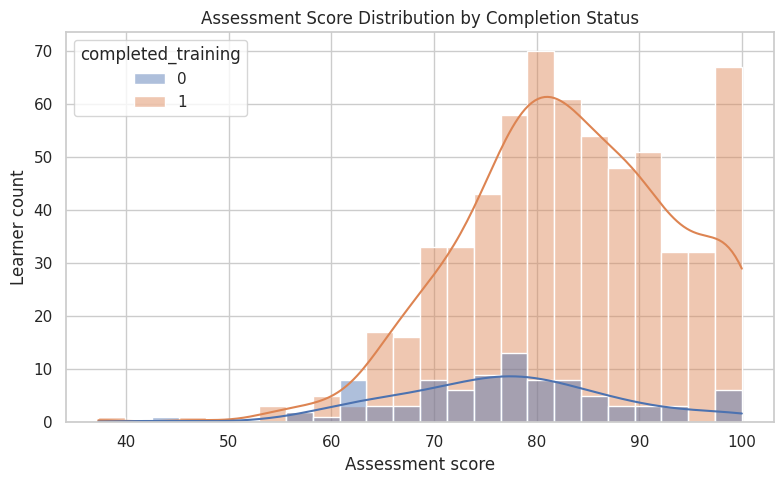

Observation: completers tend to have a higher assessment-score distribution.
Modelling implication: assessment_score may be predictive, but check whether it is available before prediction time.


In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="assessment_score", hue="completed_training", bins=24, kde=True, alpha=0.45)
plt.title("Assessment Score Distribution by Completion Status")
plt.xlabel("Assessment score")
plt.ylabel("Learner count")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_distribution_assessment_score.png", dpi=180)
plt.show()

print("Observation: completers tend to have a higher assessment-score distribution.")
print("Modelling implication: assessment_score may be predictive, but check whether it is available before prediction time.")

## 4. Plot 2: Completion rate by training mode

Question: does completion differ by training mode?

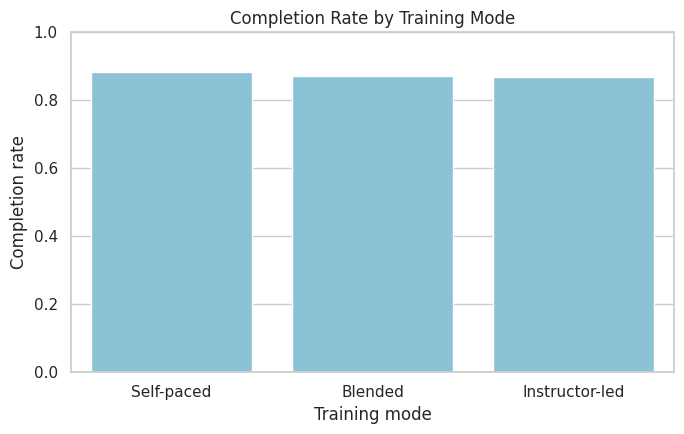

,training_mode,completed_training
0,Self-paced,0.881919
1,Blended,0.872180
2,Instructor-led,0.868852


In [8]:
completion_by_mode = (
    df.groupby("training_mode")["completed_training"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=completion_by_mode, x="training_mode", y="completed_training", color="#7EC8E3")
plt.title("Completion Rate by Training Mode")
plt.xlabel("Training mode")
plt.ylabel("Completion rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(CHART_DIR / "02_completion_by_training_mode.png", dpi=180)
plt.show()

completion_by_mode

## 5. Plot 3: Correlation heatmap

Question: which numerical variables move together? Correlation does not prove causation, but it suggests relationships worth testing.

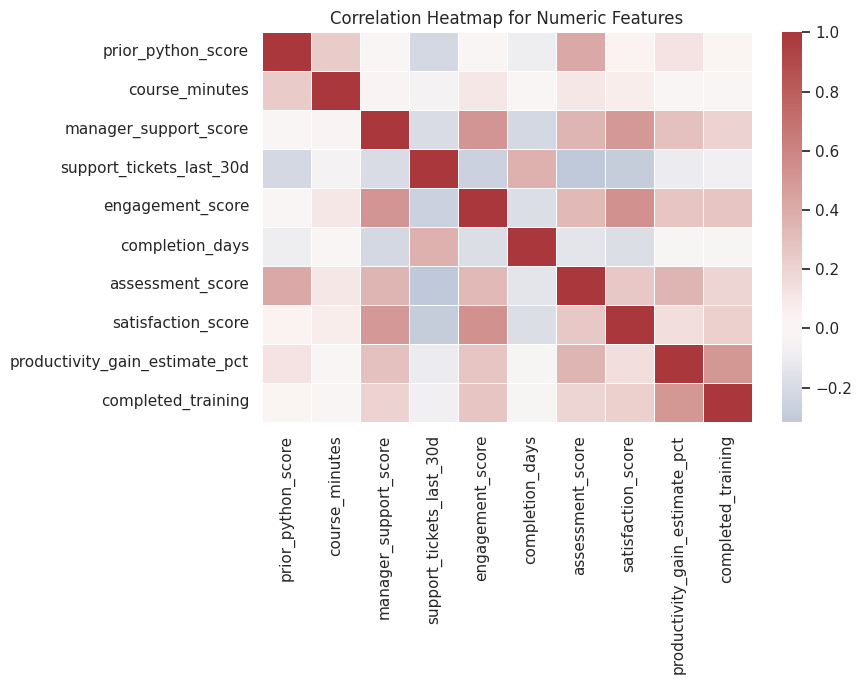

In [9]:
corr_cols = numeric_cols + ["completed_training"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(numeric_only=True), cmap="vlag", center=0, linewidths=.4)
plt.title("Correlation Heatmap for Numeric Features")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_correlation_heatmap.png", dpi=180)
plt.show()

## 6. Plot 4: Feature-target relationship

Question: is engagement different for learners who completed training versus those who did not?

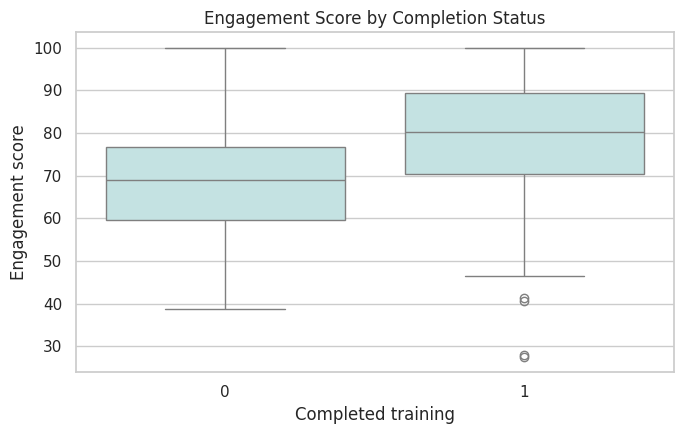

Observation: completers generally show higher engagement scores.
Modelling implication: engagement_score may be useful, but timing matters. If measured after completion, it could leak outcome information.


In [10]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="completed_training", y="engagement_score", color="#BFE7E7")
plt.title("Engagement Score by Completion Status")
plt.xlabel("Completed training")
plt.ylabel("Engagement score")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_engagement_vs_completion.png", dpi=180)
plt.show()

print("Observation: completers generally show higher engagement scores.")
print("Modelling implication: engagement_score may be useful, but timing matters. If measured after completion, it could leak outcome information.")

## 7. Plot 5: Stakeholder-facing chart

Question: what message would a learning manager need to hear?

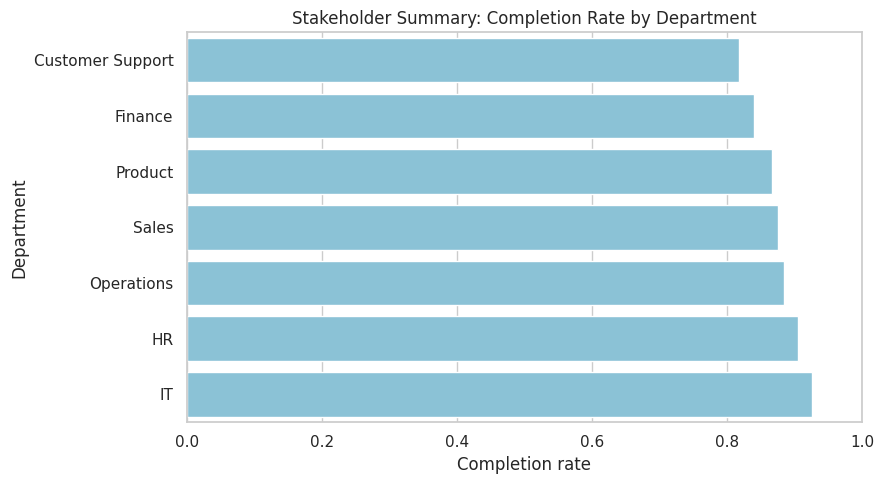

,department,completion_rate,avg_engagement,records
0,Customer Support,0.818182,77.055455,110
1,Finance,0.840000,77.292000,75
2,Product,0.866667,78.428889,90
3,Sales,0.875969,80.296124,129
4,Operations,0.885246,78.961475,122
5,HR,0.905882,75.956471,85
6,IT,0.926606,77.859633,109


In [11]:
summary = (
    df.groupby("department")
      .agg(completion_rate=("completed_training", "mean"),
           avg_engagement=("engagement_score", "mean"),
           records=("learner_record_id", "count"))
      .sort_values("completion_rate", ascending=True)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x="completion_rate", y="department", color="#7EC8E3")
plt.title("Stakeholder Summary: Completion Rate by Department")
plt.xlabel("Completion rate")
plt.ylabel("Department")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(CHART_DIR / "05_stakeholder_completion_by_department.png", dpi=180)
plt.show()

summary

## 8. Convert charts into modelling hypotheses

Complete the statements below after reviewing your charts.

In [12]:
hypotheses = [
    "H1: engagement_score may help predict completed_training because completers show higher engagement.",
    "H2: training_mode may help because completion rates differ by delivery format.",
    "H3: support_tickets_last_30d may indicate friction and may be negatively related to completion.",
    "Leakage caveat: assessment_score and productivity_gain_estimate_pct may not be available before the prediction decision."
]
for h in hypotheses:
    print("-", h)

- H1: engagement_score may help predict completed_training because completers show higher engagement.
- H2: training_mode may help because completion rates differ by delivery format.
- H3: support_tickets_last_30d may indicate friction and may be negatively related to completion.
- Leakage caveat: assessment_score and productivity_gain_estimate_pct may not be available before the prediction decision.


## 9. Student exercise

Create one additional chart of your choice. It must include:

1. A clear question.
2. A chart title and axis labels.
3. One written observation.
4. One modelling implication.
5. One caveat about bias, leakage, sample size, or timing.

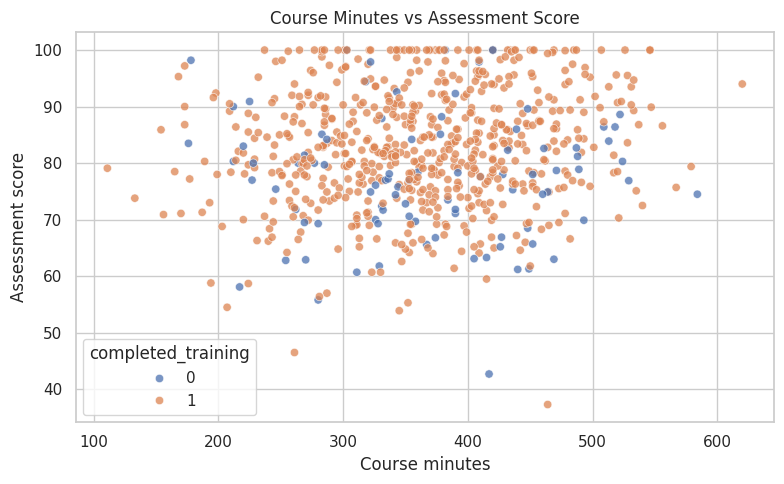

Observation: write your observation here.
Modelling implication: write your modelling implication here.
Caveat: write one caveat here.


In [13]:
# Student exercise starter cell
# Replace the column names and chart type if you want to explore a different question.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="course_minutes", y="assessment_score", hue="completed_training", alpha=0.75)
plt.title("Course Minutes vs Assessment Score")
plt.xlabel("Course minutes")
plt.ylabel("Assessment score")
plt.tight_layout()
plt.savefig(CHART_DIR / "student_exercise_chart.png", dpi=180)
plt.show()

print("Observation: write your observation here.")
print("Modelling implication: write your modelling implication here.")
print("Caveat: write one caveat here.")

## 9b. Student exercise — completed: Do high support-ticket learners complete less often?

**Question:** Are learners with many open support tickets less likely to complete training?

The raw correlation with `support_tickets_last_30d` was only -0.08, but a linear correlation hides non-linear patterns. Banding the variable should expose any threshold effect.

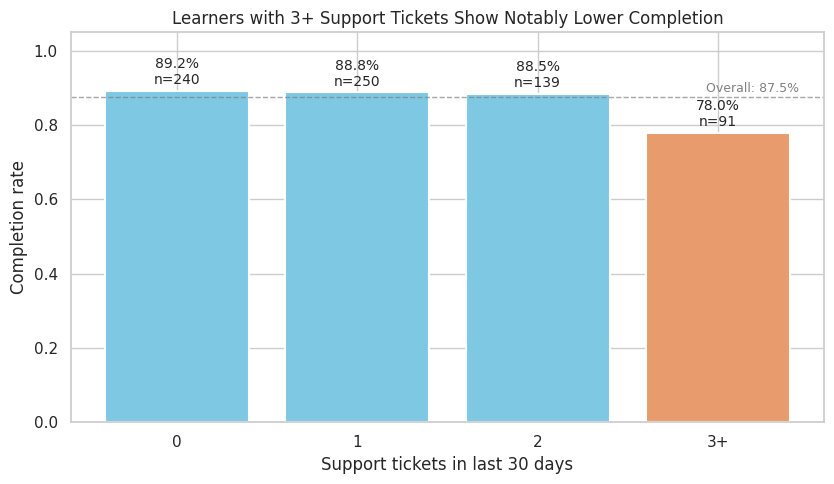

Observation: completion is flat (~88-89%) for 0-2 tickets, then drops to 78% at 3+.
Modelling implication: a 'high-friction' binary flag (>=3 tickets) is more useful than the raw count;
                       tree-based models can find this threshold automatically.
Caveat: only 91 learners in the 3+ band (5 with 5+ tickets) - the tail estimate is noisy.
        Also check that tickets are counted BEFORE the training period to avoid timing leakage.


,ticket_band,n,completion_rate
0,0,240,0.891667
1,1,250,0.888000
2,2,139,0.884892
3,3+,91,0.780220


In [14]:
# Student exercise: Do learners with many support tickets complete less often?

# Band the ticket count to handle the long tail (only 5 learners have 5+)
df["ticket_band"] = pd.cut(
    df["support_tickets_last_30d"],
    bins=[-1, 0, 1, 2, 100],
    labels=["0", "1", "2", "3+"]
)

summary = (
    df.groupby("ticket_band", observed=True)
      .agg(n=("completed_training", "size"),
           completion_rate=("completed_training", "mean"))
      .reset_index()
)

# Highlight the at-risk band in a different colour
colors = ["#7EC8E3" if r >= 0.85 else "#E89B6C" for r in summary["completion_rate"]]

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(summary["ticket_band"], summary["completion_rate"],
              color=colors, edgecolor="white", linewidth=1.5)

# Overall completion rate as a reference line
overall = df["completed_training"].mean()
ax.axhline(overall, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.text(3.45, overall + 0.005, f"Overall: {overall:.1%}",
        color="grey", fontsize=9, va="bottom", ha="right")

# Annotate bars with rate + sample size
for bar, rate, n in zip(bars, summary["completion_rate"], summary["n"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}\nn={n}", ha="center", va="bottom", fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_xlabel("Support tickets in last 30 days")
ax.set_ylabel("Completion rate")
ax.set_title("Learners with 3+ Support Tickets Show Notably Lower Completion")
plt.tight_layout()
plt.savefig(CHART_DIR / "student_exercise_completion_by_tickets.png", dpi=180)
plt.show()

print("Observation: completion is flat (~88-89%) for 0-2 tickets, then drops to 78% at 3+.")
print("Modelling implication: a 'high-friction' binary flag (>=3 tickets) is more useful than the raw count;")
print("                       tree-based models can find this threshold automatically.")
print("Caveat: only 91 learners in the 3+ band (5 with 5+ tickets) - the tail estimate is noisy.")
print("        Also check that tickets are counted BEFORE the training period to avoid timing leakage.")

summary
